In [1]:
import h5py
import numpy as np

# Path to your .mat file
mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\ethernet_packets_1_1000.mat'

# Open with h5py
with h5py.File(mat_file, 'r') as f:
    # List all keys
    print("Keys in MAT file:", list(f.keys()))
    
    # Access packets dataset
    packets = np.array(f['packets'])  # shape: (recordLength, numFrames)
    
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

print(f"Sample Rate: {sample_rate} Hz")
print(f"Trigger Level: {trigger_level} V")
print(f"Record Length: {record_length} samples per packet")
print(f"Number of Packets: {num_frames}")

Keys in MAT file: ['#refs#', 'metadata', 'packets']
Sample Rate: 1250000000.0 Hz
Trigger Level: -0.5 V
Record Length: 250000.0 samples per packet
Number of Packets: 1000.0


In [2]:
reference_mat_file = r'E:\Thesis\thesis_code\data\oscilloscope\reference_packet.mat'

In [3]:
with h5py.File(reference_mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)

In [4]:
reference_packet = reference_packet[0, :]

In [5]:
reference_packet

array([ 0.03296875,  0.0140625 , -0.00929687, ..., -0.01664062,
       -0.02210938,  0.00671875], shape=(250000,))

In [6]:
packets[1,:]

array([ 0.031875  ,  0.01226563, -0.00039063, ...,  0.00421875,
       -0.00554687,  0.00726563], shape=(250000,))

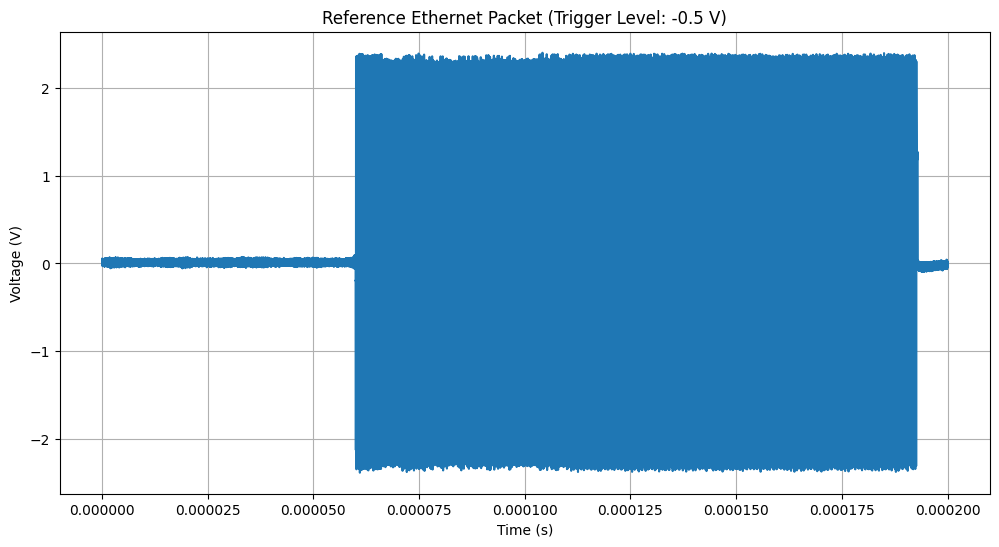

In [7]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.arange(record_length) / sample_rate

plt.figure(figsize=(12,6))
plt.plot(time_axis, reference_packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

<Figure size 1200x600 with 0 Axes>

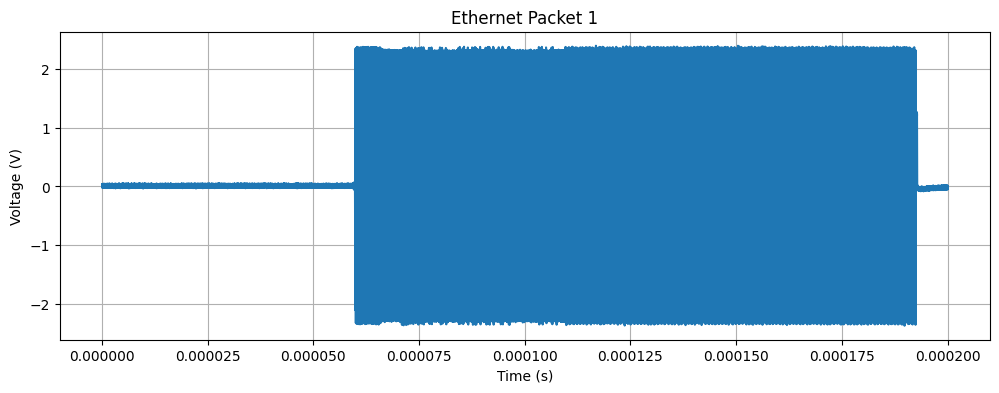

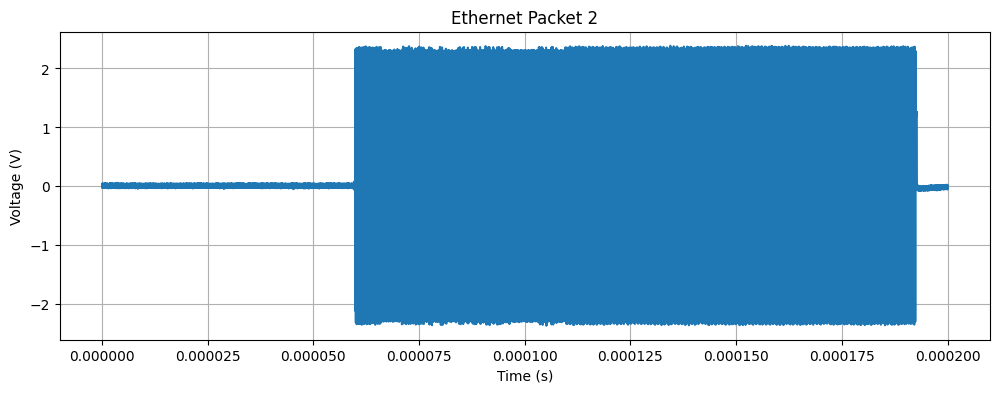

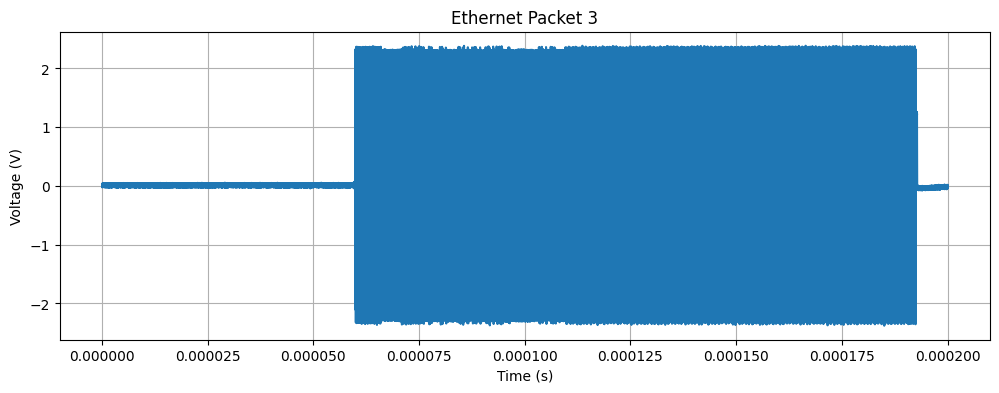

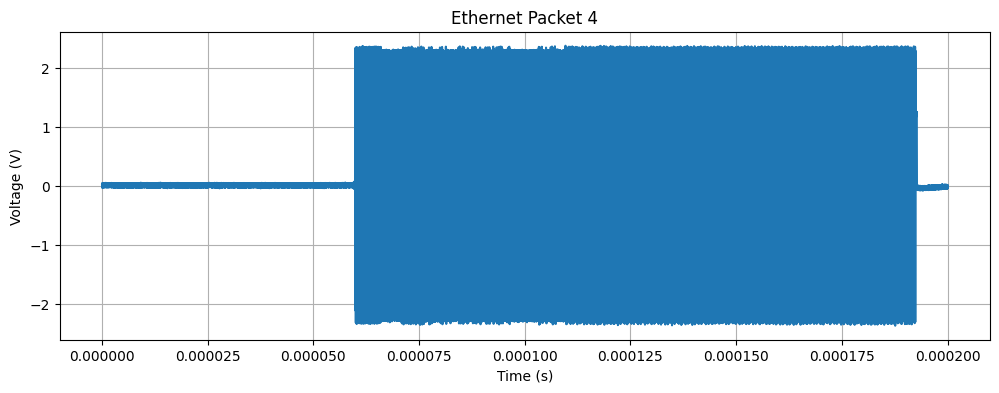

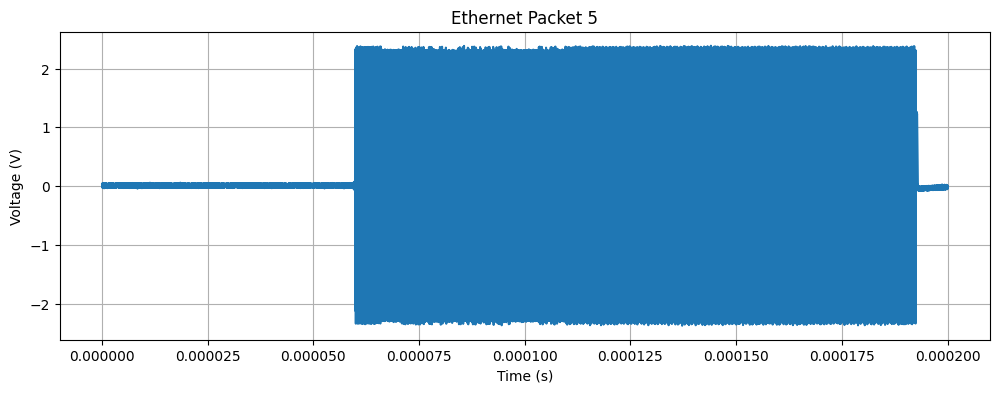

In [8]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.arange(record_length) / sample_rate

plt.figure(figsize=(12,6))

for i in range(5):
    plt.figure(figsize=(12,4))
    plt.plot(time_axis, packets[i, :])
    plt.title(f'Ethernet Packet {i+1}')
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.grid(True)
    plt.show()

In [9]:
from scipy.signal import correlate

In [ ]:
wrong_packets_count = 0
for packet in packets:
    # 1. Zero-mean 
    x = packet - np.mean(packet)
    y = reference_packet - np.mean(reference_packet)

    # 2. Compute raw correlation
    corr = correlate(x, y, mode='full')
    
    # 3. Compute normalization factor (Standard Deviations)
    # This scales the result to be between -1 and 1
    norm_factor = np.sqrt(np.sum(x**2) * np.sum(y**2))
    corr_normalized = corr / norm_factor

    # 4. Find the best match
    best_match_idx = np.argmax(corr_normalized)
    max_corr_value = corr_normalized[best_match_idx]
    lag = best_match_idx - (len(y) - 1)

    if max_corr_value < 0.8:  # Threshold for "wrong" packets (tune as needed)
        wrong_packets_count += 1
        print(f"Packet classified as WRONG: Lag={lag}, Similarity={max_corr_value:.4f}")

    # print(f"Lag: {lag} samples | Similarity: {max_corr_value:.4f}")

Lag: -194 samples | Similarity: 0.9545
Lag: -194 samples | Similarity: 0.9444
Lag: -194 samples | Similarity: 0.9528
Lag: -194 samples | Similarity: 0.9568
Lag: -194 samples | Similarity: 0.9460
Lag: -194 samples | Similarity: 0.9615
Lag: -194 samples | Similarity: 0.9571
Lag: -194 samples | Similarity: 0.9580
Lag: -194 samples | Similarity: 0.9513
Lag: -195 samples | Similarity: 0.9437
Lag: -195 samples | Similarity: 0.9535
Lag: -194 samples | Similarity: 0.9515
Lag: -194 samples | Similarity: 0.9566
Lag: -194 samples | Similarity: 0.9558
Lag: -194 samples | Similarity: 0.9514
Lag: -194 samples | Similarity: 0.9433
Lag: -194 samples | Similarity: 0.9463
Lag: -194 samples | Similarity: 0.9637
Lag: -194 samples | Similarity: 0.9565
Lag: -194 samples | Similarity: 0.9522
Lag: -194 samples | Similarity: 0.9466
Lag: -194 samples | Similarity: 0.9542
Lag: -194 samples | Similarity: 0.9433
Lag: -194 samples | Similarity: 0.9424
Lag: -194 samples | Similarity: 0.9401
Lag: -194 samples | Simil

In [11]:
print(f"Total Wrong Packets: {wrong_packets_count} out of {len(packets)}")

Total Wrong Packets: 4 out of 1000


In [22]:
from scipy.signal import correlate

corr = correlate(reference_packet, packets[2], mode='full')
lag = np.argmax(corr) - len(reference_packet) + 1
print("Best alignment lag:", lag)
print("Alignment value:", corr[np.argmax(corr)])

Best alignment lag: 0
Alignment value: 383924.69585234375
